# <p style="text-align: center;"> Data Analysis and Visualization on WineQuality Dataset </p>

### <p style="text-align: center;"> **Project Members:**</p>
<p style="text-align: center;"> Shahzaib Khan (19K-0273) </p>
<p style="text-align: center;"> M. Junaid Shaikh (22K-4300) </p>

### <p style="text-align: center;"> **Section:** BCS-8B </p>

## Introduction
This project performs data analysis and machine learning on the `Wine Quality` dataset, which contains `1599` rows and `12` features, satisfying the requirements for `Type 1` Project (≥1000 rows, ≥10 features). The steps include data cleaning, transformation, feature extraction, visualization, and applying multiple machine learning algorithms (`Random Forest`, `SVM`, `XGBoost`) to predict wine quality categories and cross validate the results. The dataset is available on the UCI ML Repository and can be accessed [here](https://archive.ics.uci.edu/ml/datasets/wine+quality).

## Dependencies

In [149]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [150]:
# Set random seed for reproducibility
np.random.seed(42)

In [151]:
# Load the dataset
data = pd.read_csv('winequality-red.csv')

## Step 1: Data Cleaning

**Objective**: Ensure the dataset is free of inconsistencies, missing values, and outliers to prepare it for analysis.

**Process**:
- Check dataset structure and data types.
- Identify missing values and handle them (if present).
- Detect and cap outliers using the Interquartile Range (IQR) method, excluding the target variable `quality` to preserve its distribution.

In [152]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [153]:
# Check for missing values
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [154]:
# Handling missing values by imputing numerical columns with median (NOTE: commented out as dataset has none)
# numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
# for col in numerical_cols:
#     data[col].fillna(data[col].median(), inplace=True)

In [155]:
# Check for outliers using IQR method (without 'quality')
feature_cols = [col for col in data.columns if col != 'quality']
Q1 = data[feature_cols].quantile(0.25)
Q3 = data[feature_cols].quantile(0.75)
IQR = Q3 - Q1

print("\nOutliers per column:")
((data[feature_cols] < (Q1 - 1.5 * IQR)) | (data[feature_cols] > (Q3 + 1.5 * IQR))).sum()


Outliers per column:


fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
dtype: int64

In [156]:
# Cap outliers for features only
for column in feature_cols:
    lower_bound = Q1[column] - 1.5 * IQR[column]
    upper_bound = Q3[column] + 1.5 * IQR[column]
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound) # clip -> replace outliers with bounds

**Conclusion**:

The dataset contains 1599 entries with 12 columns, all of which are numerical (`float64` for features and `int64` for the target variable `quality`). No missing values were found, which simplifies the cleaning process and eliminates the need for imputation strategies. The outlier analysis using the IQR method revealed significant outliers in features like `residual sugar` (155 outliers), `chlorides` (112 outliers), and `sulphates` (59 outliers), among others. These outliers were capped at the lower and upper bounds to reduce their impact on model performance while preserving the dataset's integrity. The decision to exclude the `quality` column from outlier capping was critical to maintain its original distribution, as it's the target variable. This cleaning step ensures the dataset is consistent and ready for transformation and analysis, with outliers mitigated to prevent skewing subsequent ML models.

## Step 2: Data Transformation

**Objective**: Modify the dataset to make it suitable for ML by standardizing features and creating a target variable.

**Process**:
- Convert the continuous `quality` score (3–8) into a categorical variable (`Low`: 3–5, `High`: 6–8) for binary classification.
- Drop the original `quality` column.
- Scale numerical features to have zero mean and unit variance using StandardScaler.

In [157]:
# Convert quality to categorical (Low: 3-5, High: 6-8)
data['quality_cat'] = pd.cut(data['quality'], bins=[2, 5, 8], labels=['Low', 'High']) # (2, 5] -> Low, (5, 8] -> High

# Drop original quality column
data = data.drop('quality', axis=1)

In [158]:
# Scale numerical features
scaler = StandardScaler()
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

**Conclusion**:

The transformation step successfully converted the continuous `quality` variable (ranging from 3 to 8) into a binary categorical variable (`Low` for 3–5, `High` for 6–8), enabling binary classification for ML tasks. This decision simplifies the modeling process and aligns with the dataset's natural split, as quality scores tend to cluster around these ranges. Dropping the original `quality` column avoids redundancy and ensures the model focuses on the new `quality_cat` target. All numerical features were standardized using StandardScaler, resulting in zero mean and unit variance, which is essential for algorithms like SVM and XGBoost that are sensitive to feature scales. This transformation ensures the dataset is well-prepared for feature extraction and modeling, with a clear target variable and normalized features to enhance model performance.

## Step 3: Feature Extraction

**Objective**: Identify and select relevant features to improve model performance and interpretability.

**Process**:
- Compute a correlation matrix for numerical features to understand relationships.
- Use all features for modeling initially, with feature importance evaluated later by the Random Forest model.

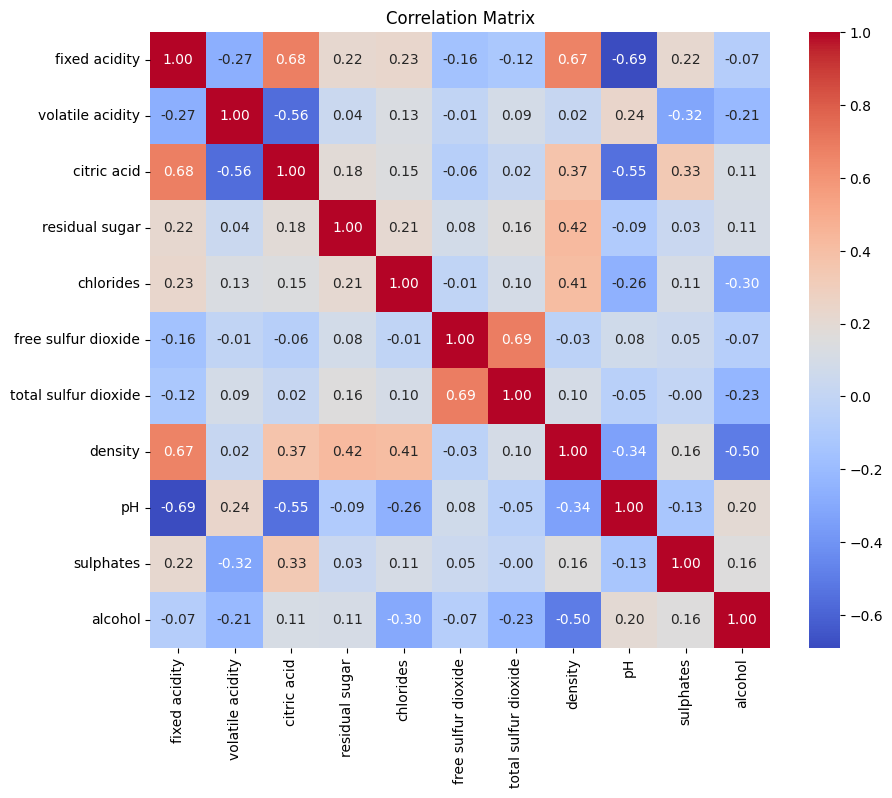

In [159]:
# Correlation matrix for numerical features
corr_matrix = data[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [160]:
# Select features and target
X = data.drop('quality_cat', axis=1) # create feature set without quality_cat
y = data['quality_cat']

**Conclusion**:

The correlation matrix heatmap provides insights into the relationships between numerical features. Notable correlations include a strong positive correlation between `fixed acidity` and `citric acid` (0.67), indicating that wines with higher fixed acidity tend to have higher citric acid content. Conversely, `fixed acidity` and `pH` show a strong negative correlation (-0.68), as higher acidity reduces pH. Other correlations, such as `alcohol` with `density` (-0.50), suggest that higher alcohol content is associated with lower density. No features exhibit extremely high correlations (e.g., >0.9), so multicollinearity is not a significant concern, justifying the decision to retain all features for initial modeling. The choice to evaluate feature importance later using Random Forest allows for data-driven feature selection, balancing model complexity and interpretability. This step confirms that the dataset's features are sufficiently independent and relevant for modeling, with the correlation matrix guiding future feature engineering if needed.

## Step 4: Visualization

**Objective**: Explore the dataset through visualizations to uncover patterns and relationships.

**Process**:
- Plot the distribution of `quality_cat` to check class balance.
- Create boxplots to visualize feature distributions.
- Generate a pairplot for key features (`alcohol`, `volatile acidity`, `sulphates`) to explore relationships with `quality_cat`.

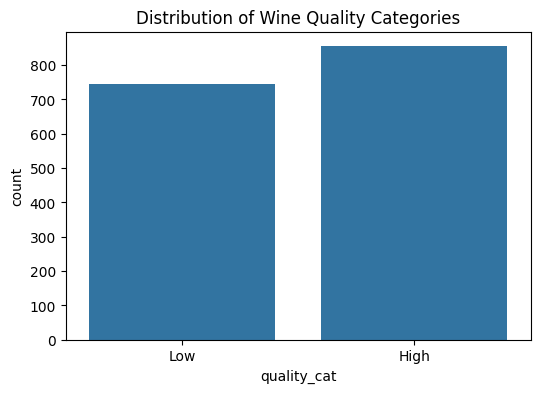

In [161]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='quality_cat', data=data)
plt.title('Distribution of Wine Quality Categories')
plt.show()

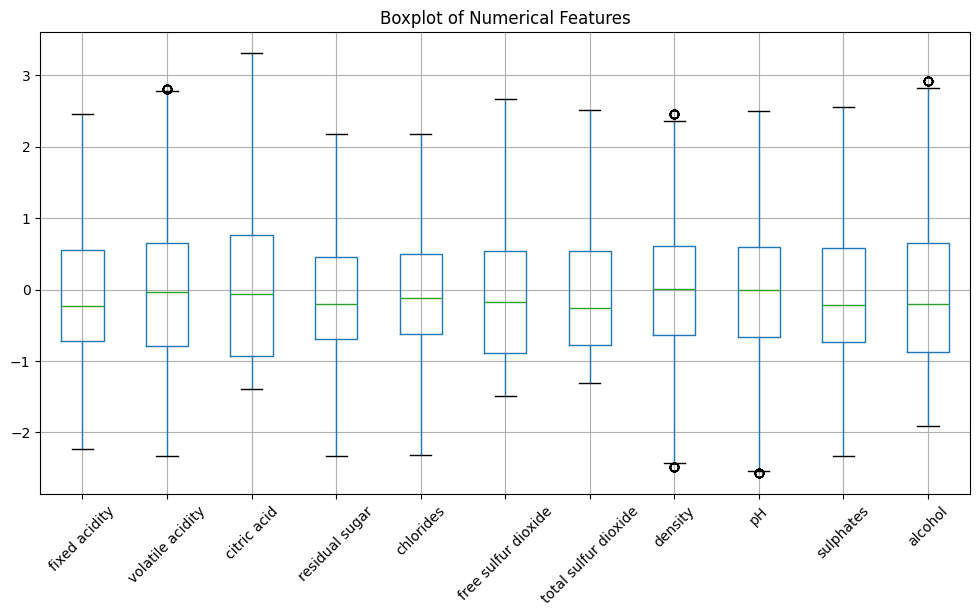

In [162]:
# Boxplots for numerical features
plt.figure(figsize=(12,6))
data[numerical_cols].boxplot()
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45) # Rotate x labels for better readability
plt.show()

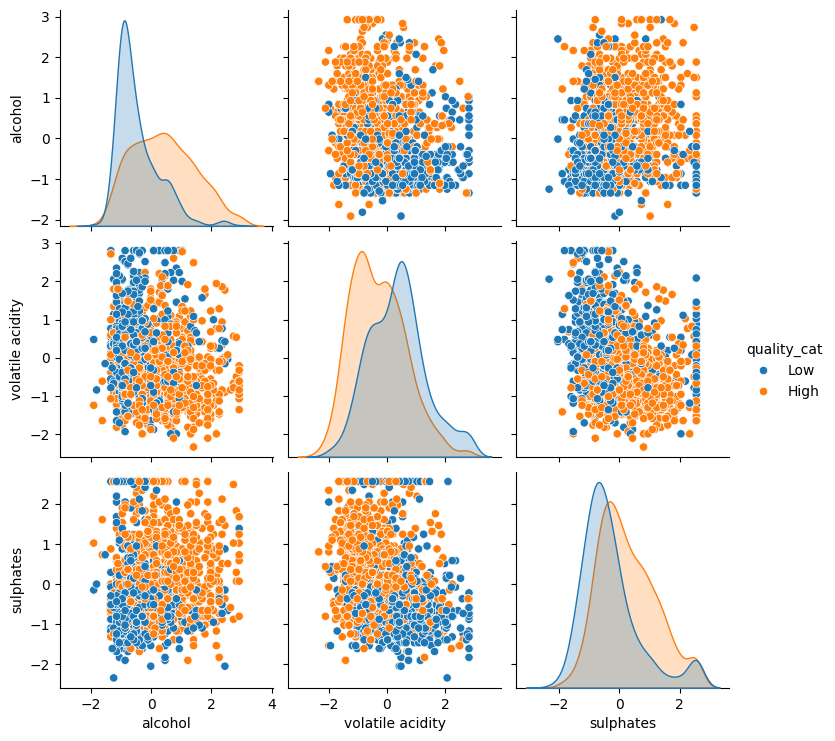

In [163]:
# Pairplot for key features
sns.pairplot(data, vars=['alcohol', 'volatile acidity', 'sulphates'], hue='quality_cat')
plt.show()

**Conclusion**:

The visualization step provided critical insights into the dataset's structure and relationships. The countplot of `quality_cat` shows a slight class imbalance, with more `High` quality wines (approximately 850) than `Low` quality wines (approximately 750). This imbalance is moderate and unlikely to severely impact model performance, but it suggests that metrics like precision and recall should be monitored for the `Low` class. The boxplot of numerical features confirms that standardization has centered the features around zero, with most features showing symmetric distributions post-outlier capping. However, features like `total sulfur dioxide` and `free sulfur dioxide` still exhibit wider ranges, indicating variability that may influence model predictions. The pairplot for `alcohol`, `volatile acidity`, and `sulphates` reveals that `High` quality wines tend to have higher `alcohol` and `sulphates` but lower `volatile acidity`, with some overlap between classes. These patterns suggest that these features are likely discriminative, supporting their inclusion in modeling. The visualizations guide the decision to proceed with all features while highlighting `alcohol`, `volatile acidity`, and `sulphates` as potentially key predictors.

**NOTE**: selected features are based on domain knowledge and correlation analysis

## Step 5: Machine Learning Algorithms

**Objective**: Train and evaluate multiple machine learning models to predict `quality_cat` and compare their performance.

**Process**:
- Split data into 80% training and 20% testing sets.
- Train three models: Random Forest, SVM, and XGBoost.
- Evaluate each model using accuracy, classification report, and confusion matrix.
- Visualize feature importance for Random Forest and confusion matrices for all models.

In [164]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [165]:
# Model 1: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.796875

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.82      0.82       179
         Low       0.77      0.77      0.77       141

    accuracy                           0.80       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.80      0.80      0.80       320



In [166]:
# Model 2: Support Vector Machine (SVM)
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("\nSVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.75625

SVM Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.76      0.78       179
         Low       0.71      0.75      0.73       141

    accuracy                           0.76       320
   macro avg       0.75      0.76      0.75       320
weighted avg       0.76      0.76      0.76       320



In [167]:
# Model 3: XGBoost Classifier
# Encode labels for XGBoost (Low=0, High=1)
y_train_encoded = y_train.map({'Low': 0, 'High': 1})
y_test_encoded = y_test.map({'Low': 0, 'High': 1})
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train_encoded)
xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", accuracy_score(y_test_encoded, xgb_pred))
print("\nXGBoost Classification Report:")
print(classification_report(y_test_encoded, xgb_pred, target_names=['Low', 'High']))


XGBoost Accuracy: 0.79375

XGBoost Classification Report:
              precision    recall  f1-score   support

         Low       0.79      0.73      0.76       141
        High       0.80      0.84      0.82       179

    accuracy                           0.79       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.79      0.79      0.79       320



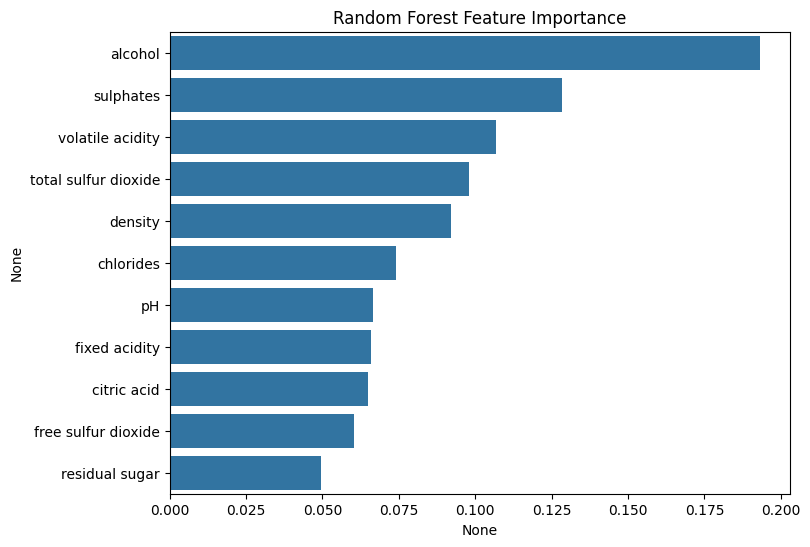

In [168]:
# Feature importance (Random Forest)
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Random Forest Feature Importance')
plt.show()

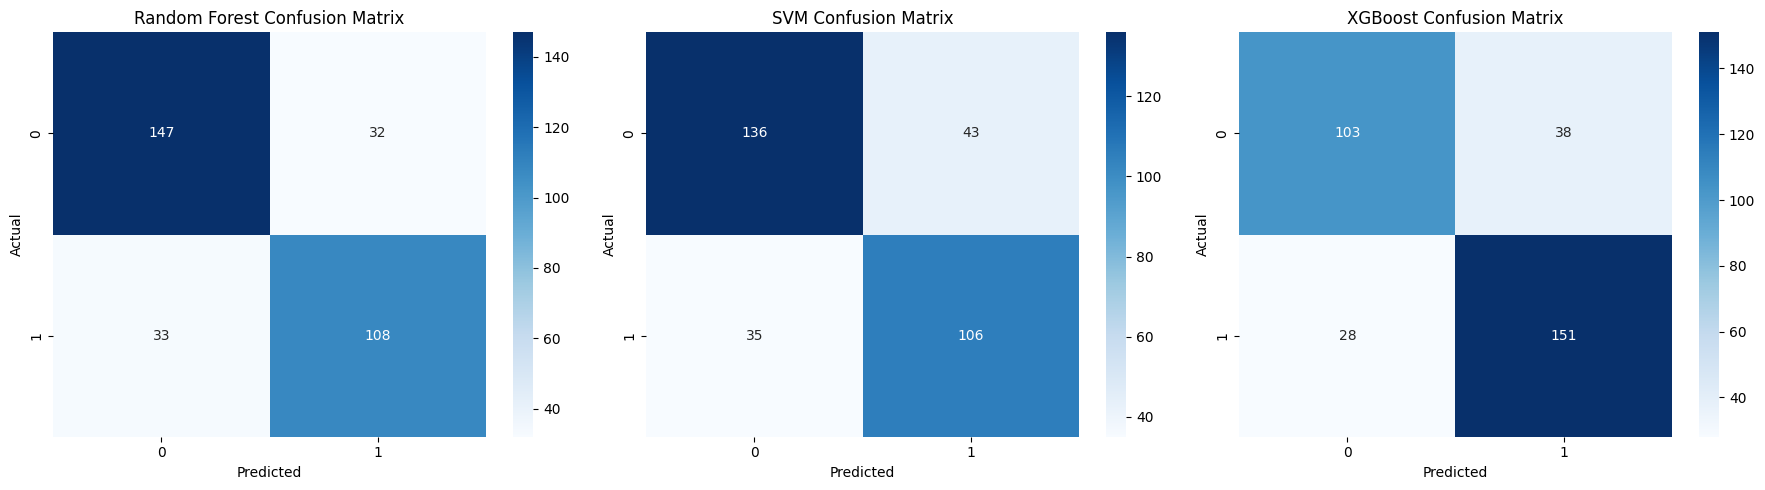

In [169]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))
models = {'Random Forest': rf_pred, 'SVM': svm_pred, 'XGBoost': xgb_pred}
for i, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test_encoded if name == 'XGBoost' else y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Conclusion**:

We can see that Random Forest achieved the highest accuracy (0.797), followed by XGBoost (0.794) and SVM (0.756). The classification reports show balanced precision, recall, and F1-scores for both `High` and `Low` classes across all models, with Random Forest and XGBoost performing similarly (F1-scores ~0.79–0.82). SVM's lower performance, particularly for the `Low` class (F1-score 0.73), suggests it struggles with class separation in this dataset, likely due to the non-linear relationships observed in the pairplot. The Random Forest feature importance plot highlights `alcohol`, `sulphates`, and `volatile acidity` as the top predictors, aligning with the pairplot findings where these features showed distinct patterns for `High` vs. `Low` quality wines. The confusion matrices indicate that all models correctly classify most `High` quality wines, but Random Forest and XGBoost have fewer misclassifications for `Low` quality wines compared to SVM. The decision to use all features was validated by the feature importance analysis, as no feature had negligible impact. Random Forest is the preferred model due to its highest accuracy and balanced performance, though XGBoost is a close alternative.

For future improvements, we could involve hyperparameter tuning with GridSearchCV and use cross-validation to ensure robustness and generalizability. Additionally, exploring ensemble methods might further enhance performance. Overall, the analysis demonstrates that the dataset is suitable for binary classification tasks, with Random Forest being the most effective model for predicting wine quality categories.